# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [2]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')
num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())
print(scene.rx_array.positions(3e8/3.5e9))

# Tx position
TX_position = [0, -2, 1.5]

tx = Transmitter("tx", TX_position)
scene.add(tx)

# Rx positions
RX_positions = [[-7, 8, 1.5], 
                [0, 8, 1.5], 
                [7, 8, 1.5], 
                [9, 0, 1.5], 
                [-9, 0, 1.5], 
                [-7, -8, 1.5], 
                [0, -8, 1.5], 
                [7, -8, 1.5]]

RX_orientations = [[-np.pi/4, 0, 0], 
                   [-np.pi/2, 0, 0], 
                   [-3*np.pi/4, 0, 0], 
                   [np.pi, 0, 0], 
                   [0, 0, 0], 
                   [np.pi/4, 0, 0], 
                   [np.pi/2, 0, 0], 
                   [3*np.pi/4, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

no-name-1      itu-concrete
elm__7         itu-glass
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])
[[0, -0.0642857, 0],
 [0, -0.0214286, 0],
 [0, 0.0214286, 0],
 [0, 0.0642857, 0]]


In [3]:
### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

### Paths computations ###

In [4]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.5 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [5]:
scene.preview(paths=paths)

[-0.         -0.54596028 -1.09192061 -1.6378809 ]
[-0. -0. -0. -0.]
[-2.68249144e-18  5.45960232e-01  1.09192022e+00  1.63788041e+00]
[-0.          0.68150811  1.36301622  2.04452427]
[ 0.         -0.68150184 -1.36300368 -2.04450558]
[-0.         -0.2409487  -0.48189738 -0.72284613]
[-0. -0. -0. -0.]
[0.         0.24095307 0.48190627 0.72285941]


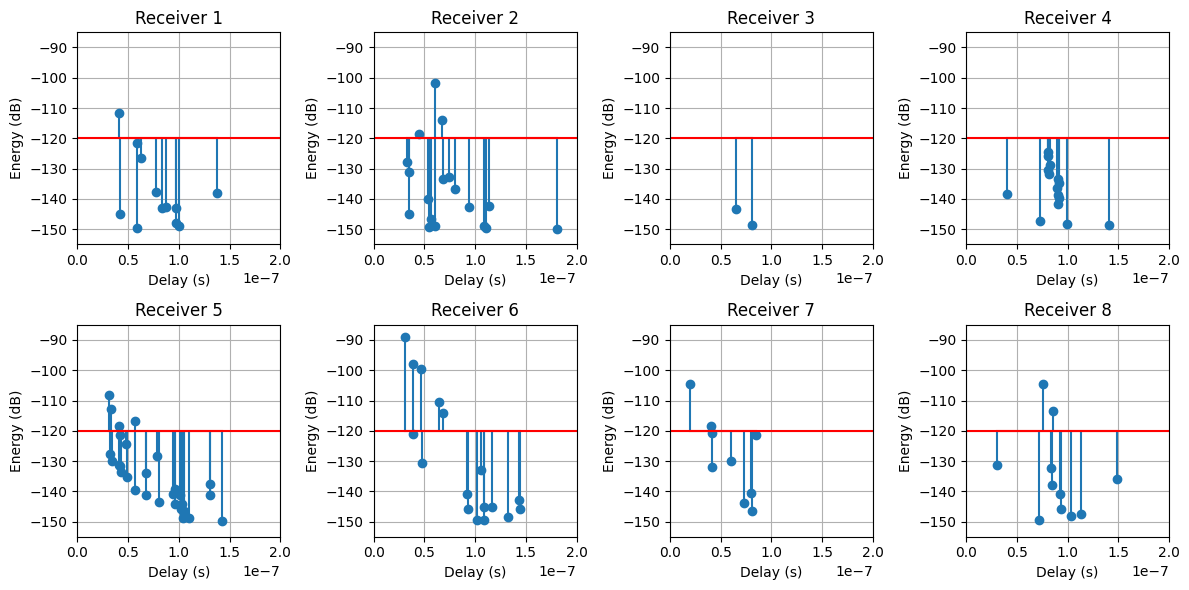

In [6]:
importlib.reload(util)

# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)

# Scale a with transmit power
a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

for i in range(len(a)):
    print(np.angle(a[i][:, 0] / a[i][0, 0]))

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(8)]
energies = [magnitudes[i]**2 for i in range(8)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(8):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

3.03010920958193e-11
3.0465744005595616e-11


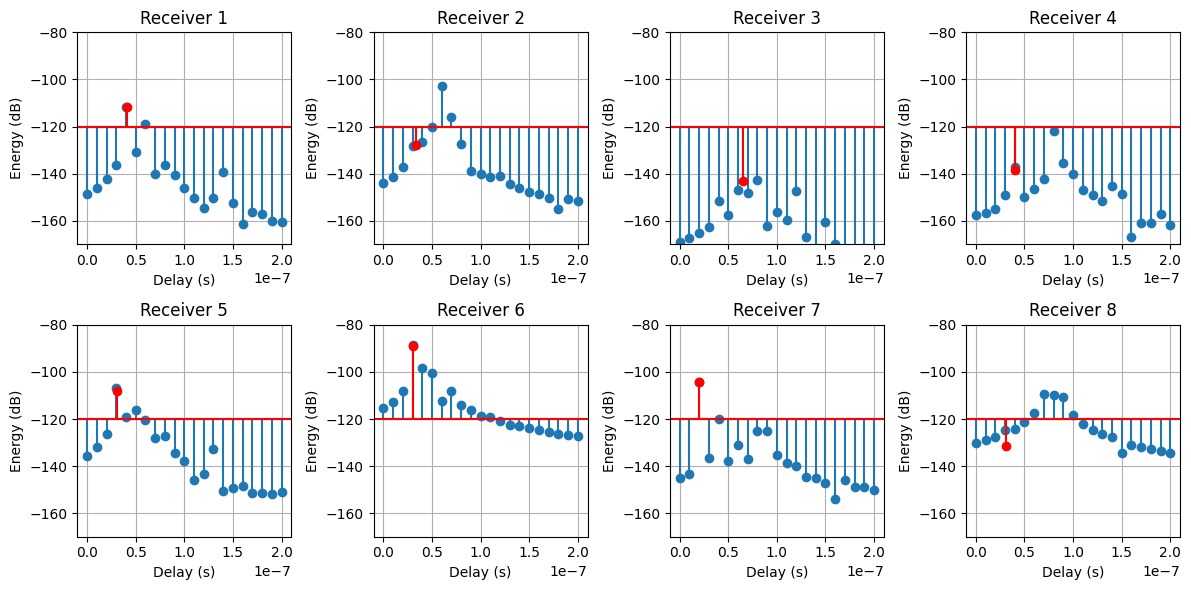

In [7]:
# Channel impulse response of the path
l_min, l_max = 0, 20
t = np.arange(l_min, l_max+1) / B

taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_energy = taps_mag ** 2


print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.stem(tau[i][0], 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim((l_min-1)/B, (l_max+1)/B)
    plt.ylim(-170, -80)
    plt.grid()
plt.tight_layout()

In [8]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)


fft_size = 256
RX_idx = 5
music_spectrum, music_tau, music_angles, K, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


R shape: (408, 408)
Optimal number of paths: 6


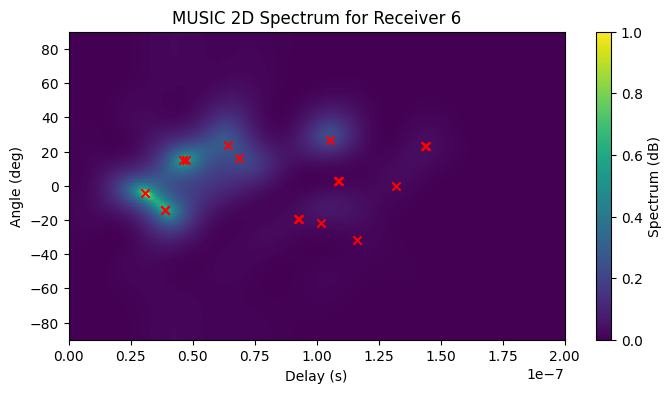

In [9]:
local_angles = util.format_local_angles(angles, RX_orientations)

plt.figure(figsize=(8, 4))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0], music_tau[-1], music_angles[0]*180/np.pi, music_angles[-1]*180/np.pi), aspect='auto', origin='lower')
plt.scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Angle (deg)")
plt.colorbar(label='Spectrum (dB)')
plt.show()

In [10]:
importlib.reload(mp)

music_spectrums = []
music_taus = []
music_angles_list = []
music_K_list = []
music_h_hats = []
for RX_idx in range(8):
    music_spectrum, music_tau, music_angles, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
    music_spectrums.append(music_spectrum)
    music_taus.append(music_tau)
    music_angles_list.append(music_angles)
    music_K_list.append(music_K)
    music_h_hats.append(music_h_hat)

R shape: (408, 408)
Optimal number of paths: 4
R shape: (408, 408)
Optimal number of paths: 4
R shape: (408, 408)
Optimal number of paths: 0
R shape: (408, 408)
Optimal number of paths: 3
R shape: (408, 408)
Optimal number of paths: 6
R shape: (408, 408)
Optimal number of paths: 6
R shape: (408, 408)
Optimal number of paths: 4
R shape: (408, 408)
Optimal number of paths: 4


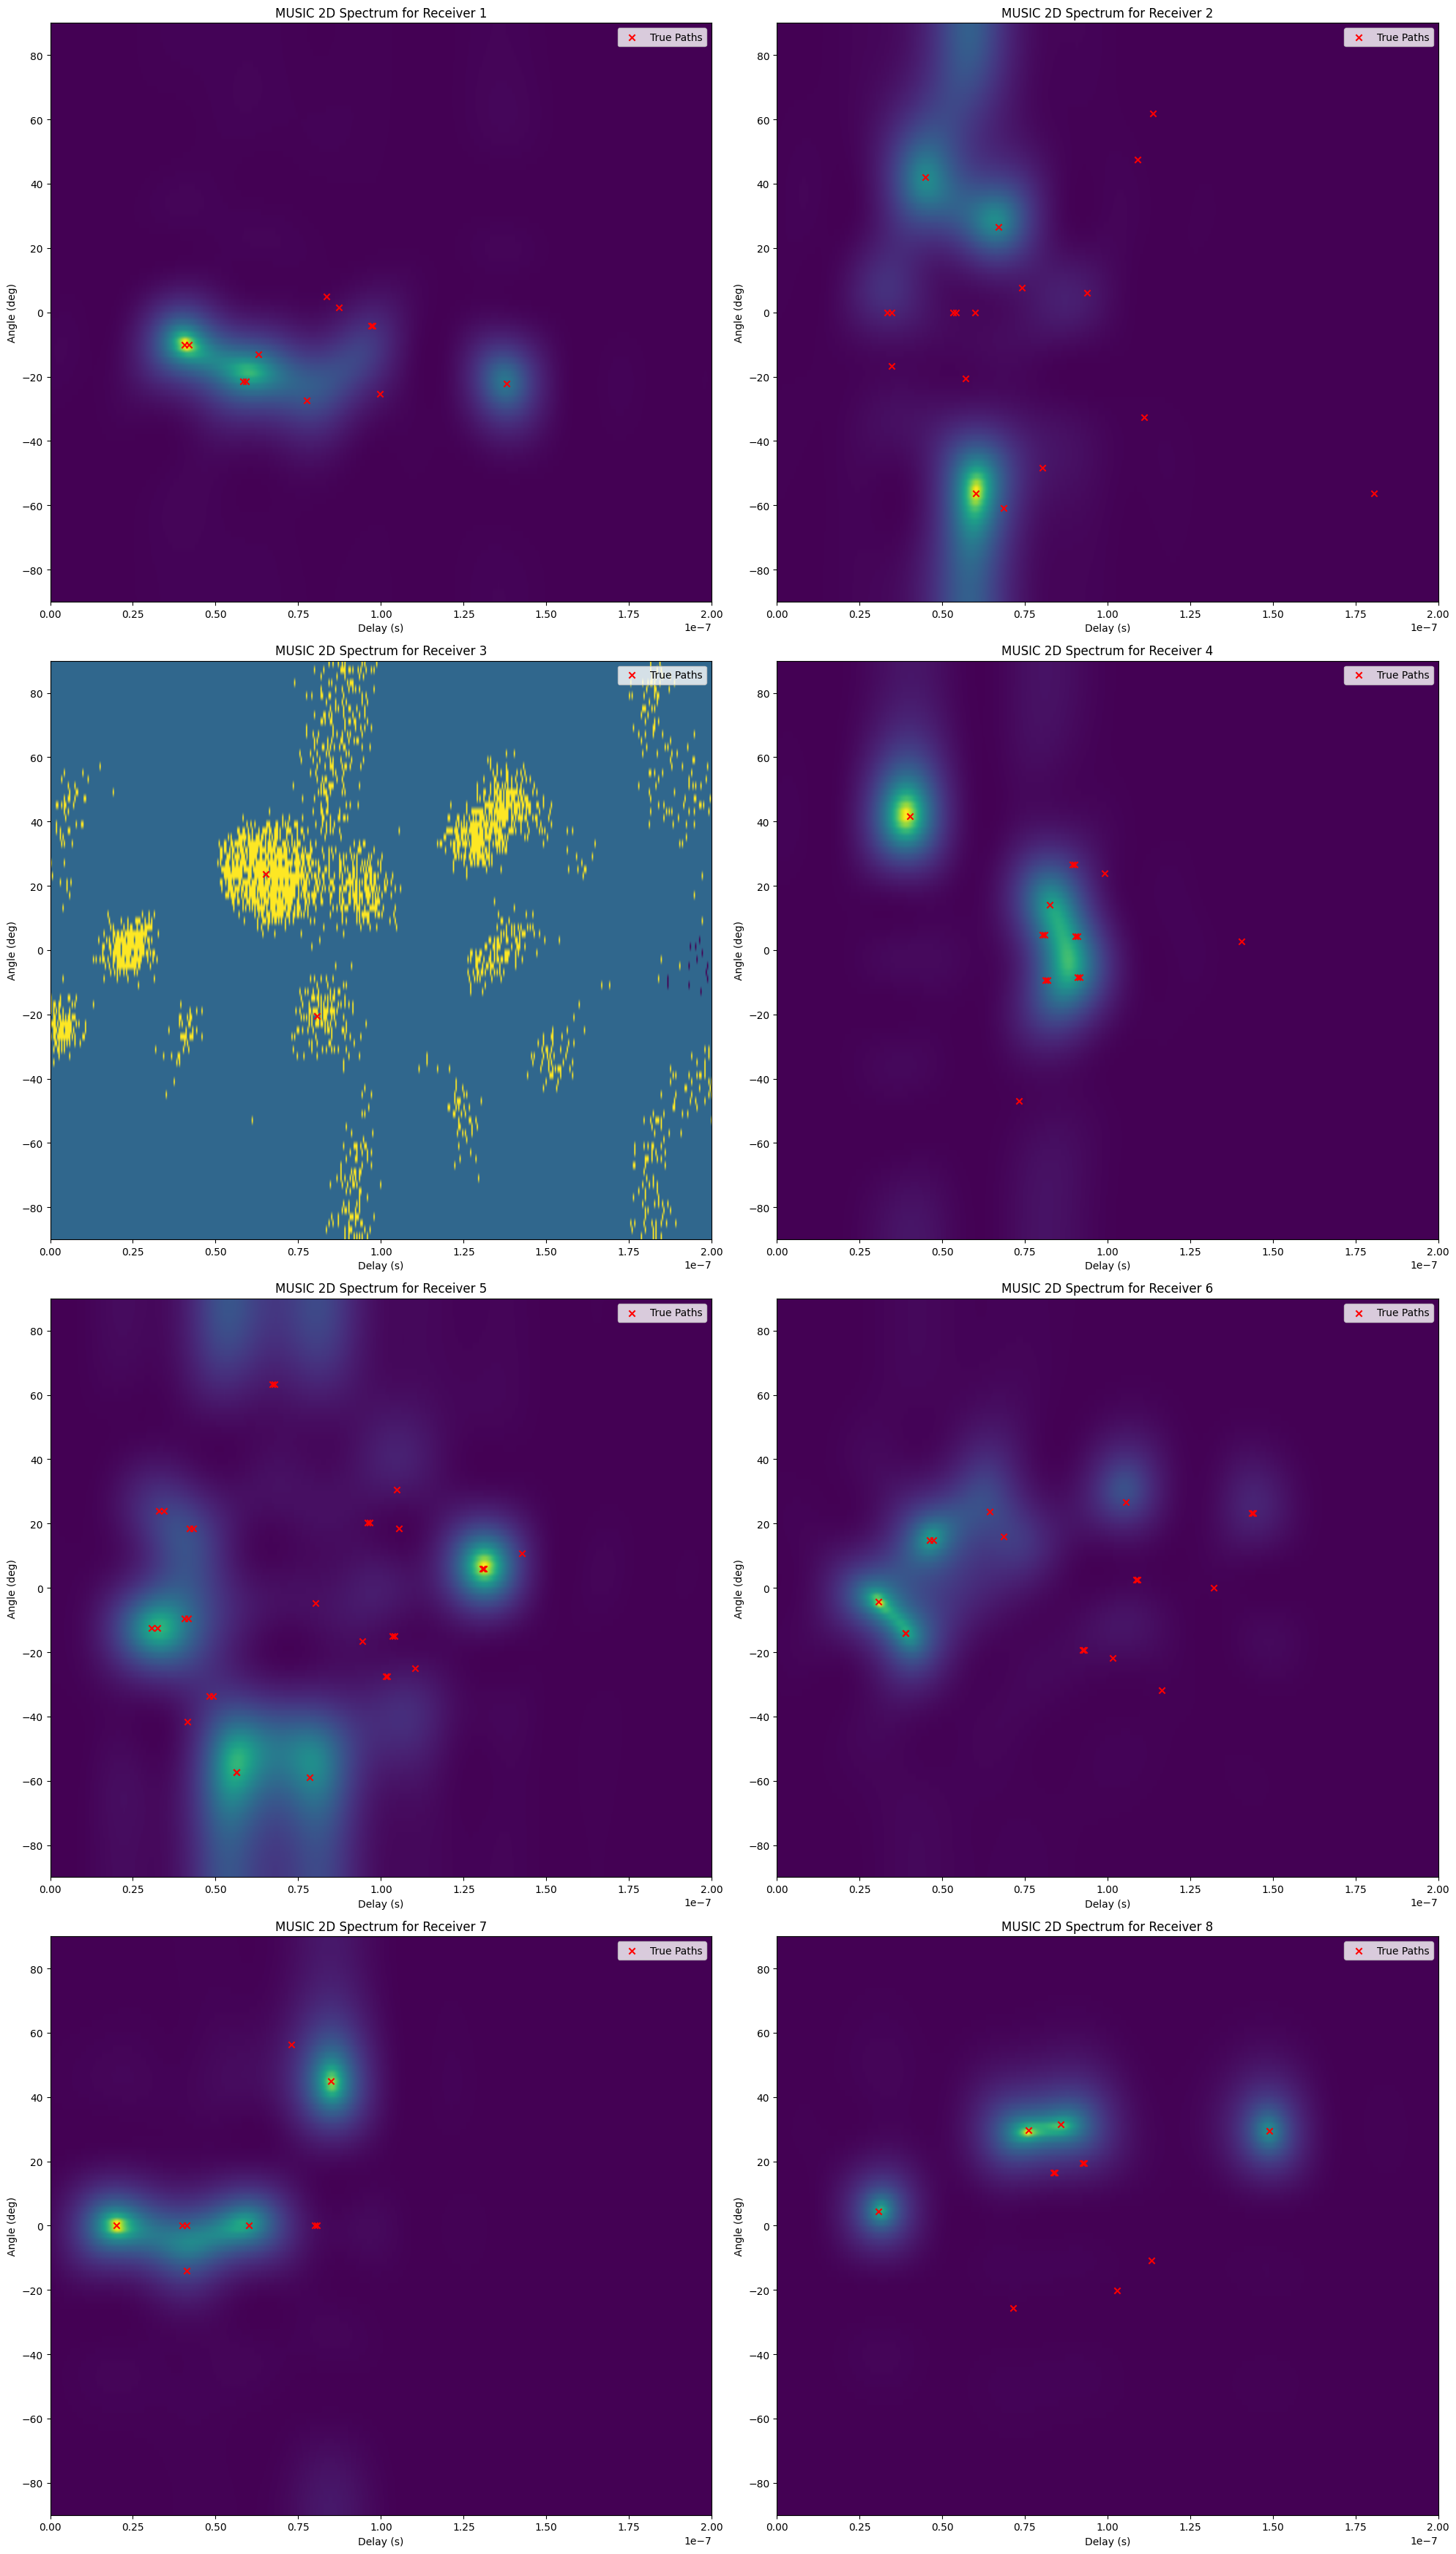

In [11]:
fig, ax = plt.subplots(4, 2, figsize=(20, 35))
for RX_idx in range(8):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles_list[RX_idx][0]*180/np.pi, music_angles_list[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

In [12]:
importlib.reload(mp)

music_taps_list = []
music_estimated_taus_list = []
music_estimated_angles_list = []
for RX_idx in range(8):
    music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                music_taus[RX_idx], 
                                                                                music_angles_list[RX_idx], 
                                                                                B/fft_size, 
                                                                                music_K_list[RX_idx], 
                                                                                music_h_hats[RX_idx])
    music_taps_list.append(music_taps)
    music_estimated_taus_list.append(music_estimated_taus)
    music_estimated_angles_list.append(music_estimated_angles)



C:\Users\louis\AppData\Local\Temp\ipykernel_26052\4019650846.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[RX_idx//2, RX_idx%2].legend()


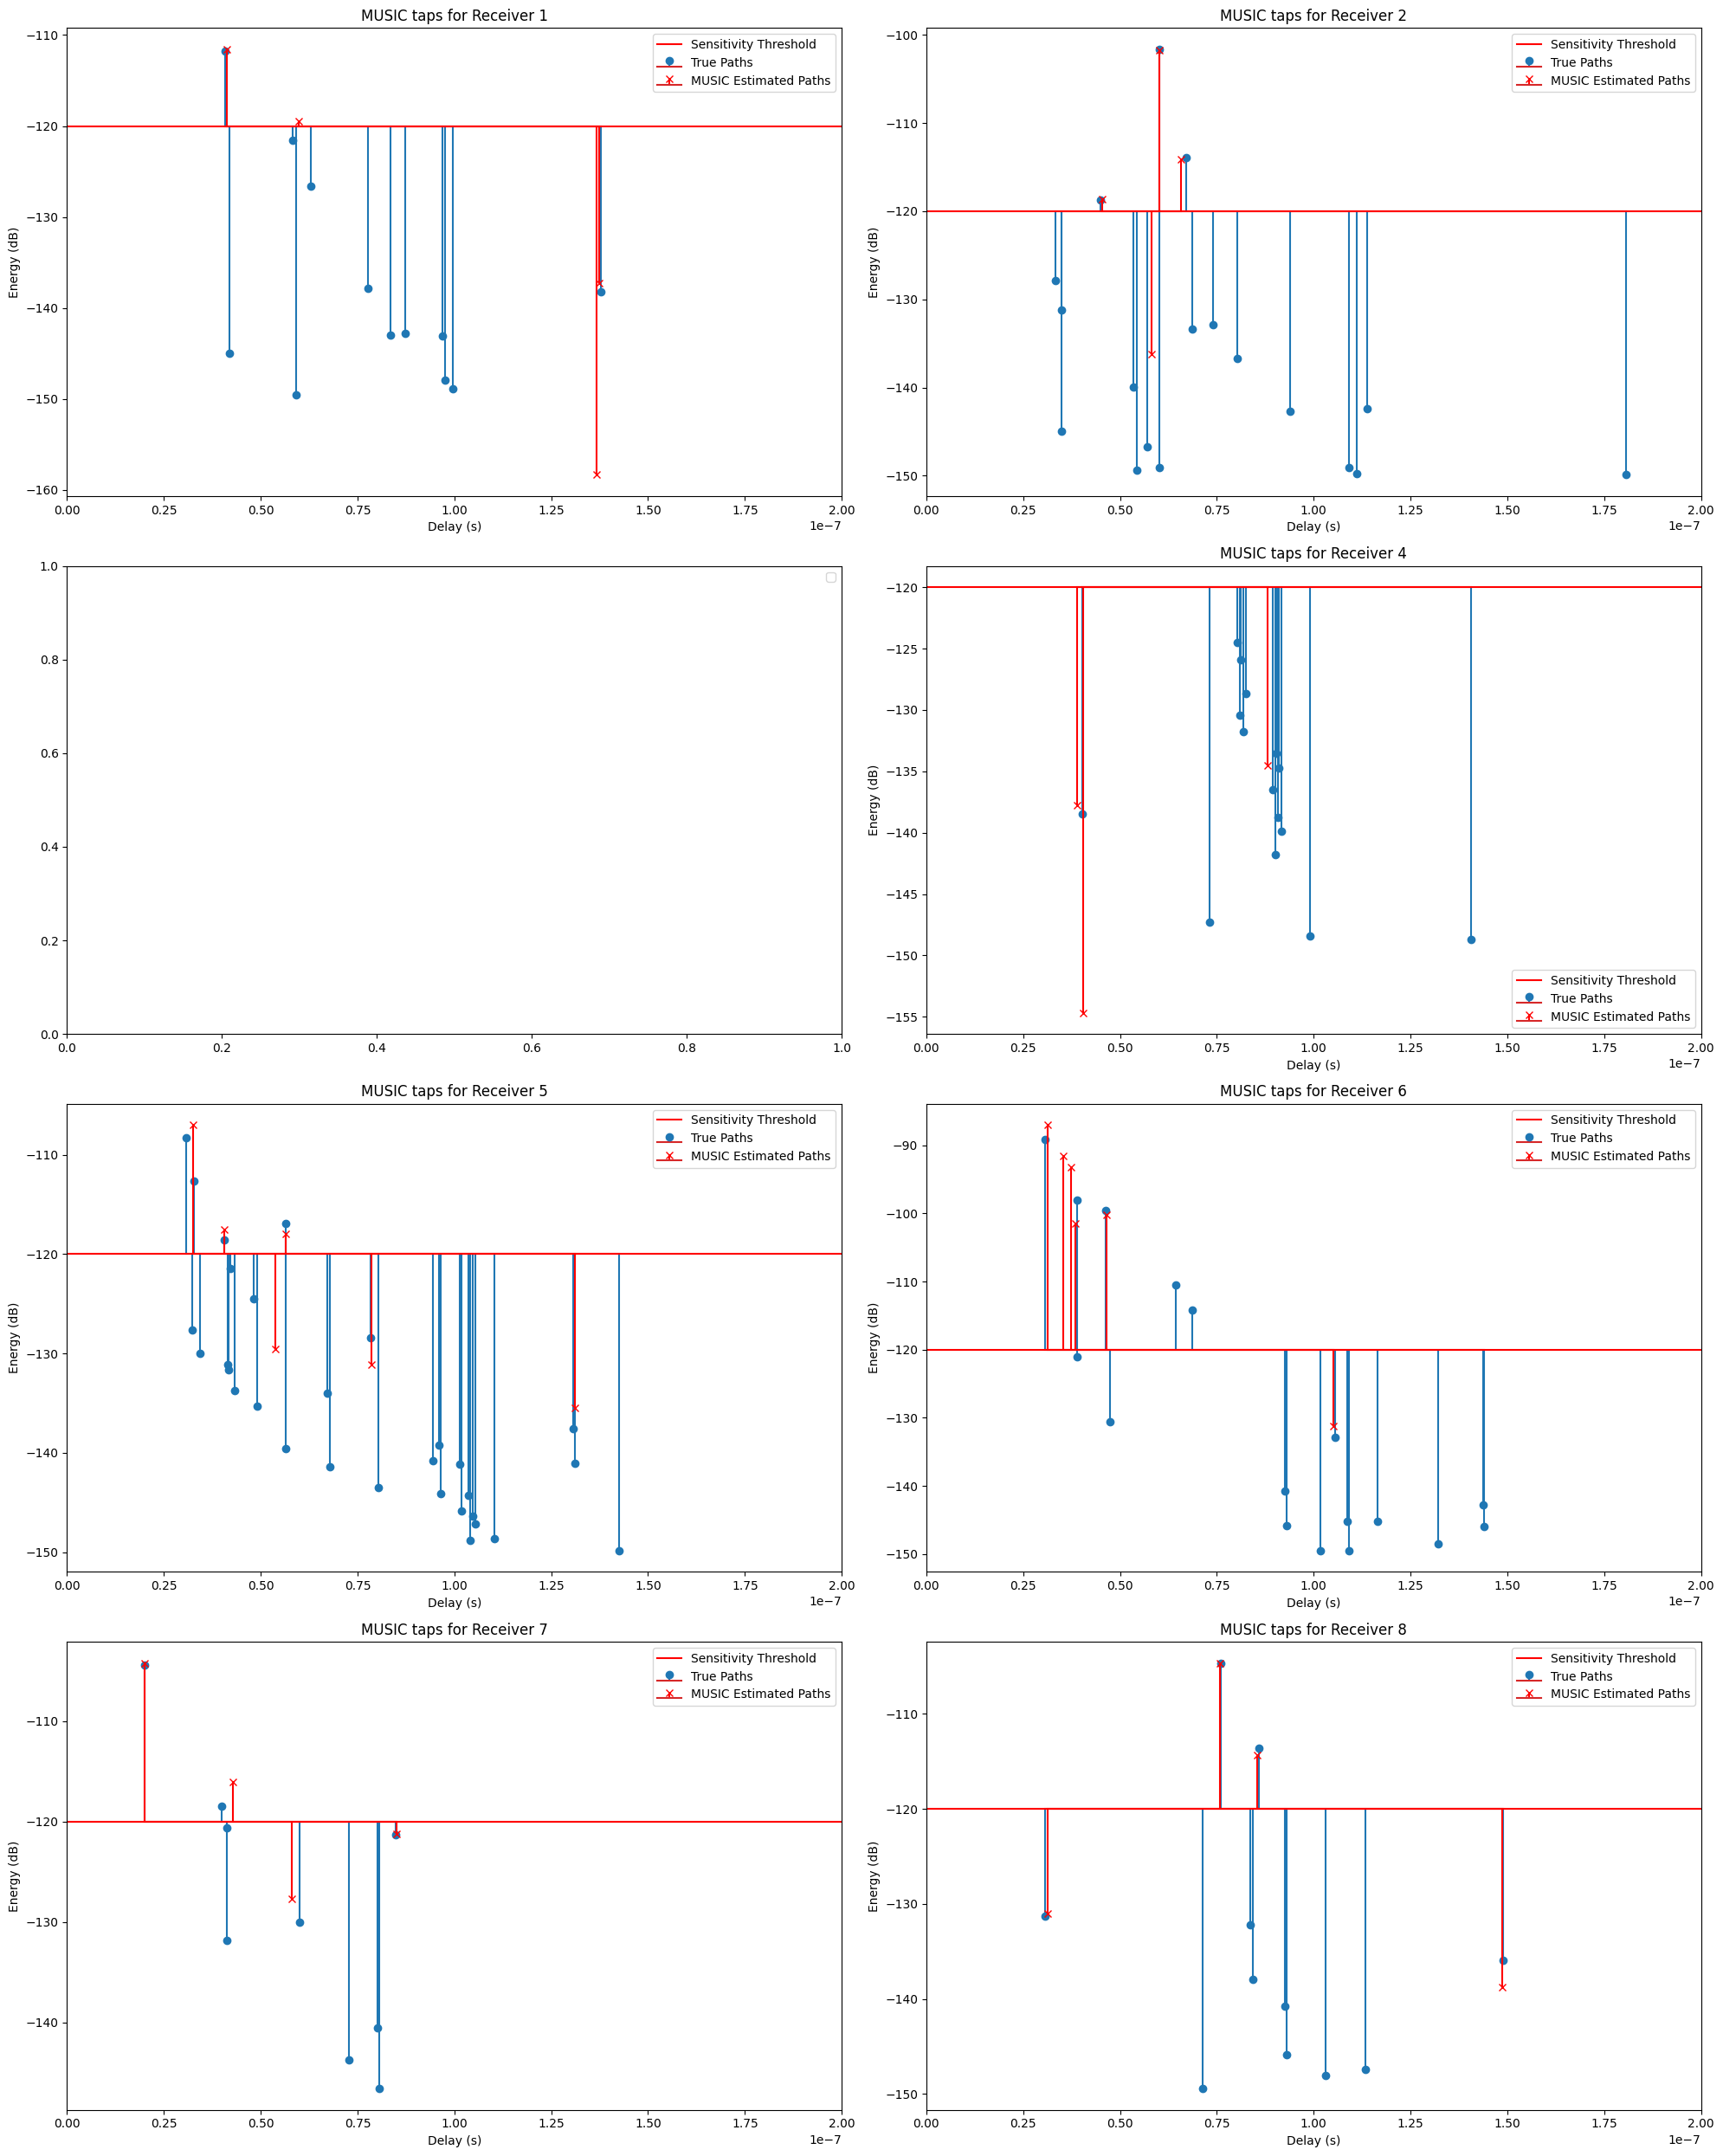

In [13]:
# Comparison of true vs estimated taps for one receiver
fig, ax = plt.subplots(4, 2, figsize=(20, 25))
for RX_idx in range(8):
    if len(music_taps_list[RX_idx]) > 0:
        ax[RX_idx//2, RX_idx%2].stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), bottom=10*np.log10(S_RX_lin), label='True Paths')
        ax[RX_idx//2, RX_idx%2].stem(music_estimated_taus_list[RX_idx], 10*np.log10(np.abs(music_taps_list[RX_idx])**2), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='rx', label='MUSIC Estimated Paths')
        ax[RX_idx//2, RX_idx%2].axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
        ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC taps for Receiver {RX_idx+1}")
        ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
        ax[RX_idx//2, RX_idx%2].set_ylabel("Energy (dB)")
        ax[RX_idx//2, RX_idx%2].set_xlim(0, 2e-7)
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()


In [33]:
import Aoa
import Tdoa
import Hybrid
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

true_first_toas = [tau[RX_idx][0] if len(tau[RX_idx]) > 0 else -1 for RX_idx in range(8)]
true_first_aoas = [angles[RX_idx][0] if len(angles[RX_idx]) > 0 else 4 for RX_idx in range(8)]

first_toas = []
for RX_idx in range(8):
    first_toa = music_estimated_taus_list[RX_idx][0] if len(music_estimated_taus_list[RX_idx]) > 0 else -1
    first_toas.append(first_toa)

first_aoas = []
for RX_idx in range(8):
    first_aoa = music_estimated_angles_list[RX_idx][0] if len(music_estimated_angles_list[RX_idx]) > 0 else 4
    # first_aoas.append(first_aoa)
    first_aoas.append(util.global_angle(first_aoa, RX_orientations[RX_idx]))


# Manual correction of wrong estimates
first_toas[1] = -1
first_aoas[1] = 4
first_toas[2] = -1
first_aoas[2] = 4
first_toas[3] = -1
first_aoas[3] = 4



for RX_idx in range(8):
    print(f"Receiver {RX_idx+1}:")
    print(f"  True First ToA: {true_first_toas[RX_idx]:.2e} s, Estimated First ToA: {first_toas[RX_idx]:.2e} s")
    print(f"  True First AoA: {true_first_aoas[RX_idx]*180/np.pi:.2f} deg, Estimated First AoA: {first_aoas[RX_idx]*180/np.pi:.2f} deg")


# TDOA localization using first path
TdoaLocalizer = Tdoa.TdoaLocalization(first_toas, [rx[:2] for rx in RX_positions])
position_estimate_tdoa = TdoaLocalizer.localize()
position_estimate_tdoa2 = TdoaLocalizer.localize_least_squares()
print("TDOA Position Estimate:", position_estimate_tdoa)
print("TDOA Least Squares Position Estimate:", position_estimate_tdoa2)

# for RX_idx in range(8):
#     print(f"Rx position: {RX_positions[RX_idx][:2]}")
#     print(f"Distance measured from toa: {first_toas[RX_idx]*3e8:.2f} m")
#     print(f"Actual distance from target: {np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - np.array(TX_position[:2])):.2f} m")



# AOA localization using first path
AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_aoa = AoaLocalizer.localize()
print("AOA Position Estimate:", position_estimate_aoa)

# Hybrid localization using tdoa and aoa
HybridLocalizer = Hybrid.HybridLocalization(first_toas, first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_hybrid = HybridLocalizer.localize()
print("Hybrid Position Estimate:", position_estimate_hybrid)

print("True Transmitter Position:", tx.position)

Receiver 1:
  True First ToA: 4.07e-08 s, Estimated First ToA: 4.13e-08 s
  True First AoA: -55.01 deg, Estimated First AoA: -56.12 deg
Receiver 2:
  True First ToA: 3.34e-08 s, Estimated First ToA: -1.00e+00 s
  True First AoA: -90.00 deg, Estimated First AoA: 229.18 deg
Receiver 3:
  True First ToA: 6.52e-08 s, Estimated First ToA: -1.00e+00 s
  True First AoA: -111.25 deg, Estimated First AoA: 229.18 deg
Receiver 4:
  True First ToA: 4.02e-08 s, Estimated First ToA: -1.00e+00 s
  True First AoA: -138.37 deg, Estimated First AoA: 229.18 deg
Receiver 5:
  True First ToA: 3.08e-08 s, Estimated First ToA: 3.25e-08 s
  True First AoA: -12.53 deg, Estimated First AoA: -13.15 deg
Receiver 6:
  True First ToA: 3.08e-08 s, Estimated First ToA: 3.13e-08 s
  True First AoA: 40.60 deg, Estimated First AoA: 39.94 deg
Receiver 7:
  True First ToA: 2.00e-08 s, Estimated First ToA: 2.00e-08 s
  True First AoA: 90.00 deg, Estimated First AoA: 91.01 deg
Receiver 8:
  True First ToA: 3.08e-08 s, Estim